In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df_CG = pd.read_csv('/home/art/test_AB_projeto/data/control_group.csv')

In [19]:
df_TG = pd.read_csv('/home/art/test_AB_projeto/data/test_group.csv')

CORRIGIR ESTRUTURA DE DAODOS PARA CRIAÇÃO DAS ANALISES


In [25]:

def fix_dataframe(df):
 
    columns = df.columns[0].split(';')
    

    data = []
    for index, row in df.iterrows():
        values = row[0].split(';')
        data.append(values)
   
    new_df = pd.DataFrame(data, columns=columns)

    numeric_columns = ['Spend [USD]', '# of Impressions', 'Reach', '# of Website Clicks', 
                      '# of Searches', '# of View Content', '# of Add to Cart', '# of Purchase']
    
    for col in numeric_columns:
        new_df[col] = pd.to_numeric(new_df[col], errors='coerce')
    
    return new_df

# Aplicar a correção
df_CG_fixed = fix_dataframe(df_CG)
df_TG_fixed = fix_dataframe(df_TG)

print("Estrutura corrigida do df_CG:")
print(df_CG_fixed.head())
print(f"\nColunas: {df_CG_fixed.columns.tolist()}")

print("\nEstrutura corrigida do df_TG:")
print(df_TG_fixed.head())
print(f"\nColunas: {df_TG_fixed.columns.tolist()}")


Estrutura corrigida do df_CG:
      Campaign Name       Date  Spend [USD]  # of Impressions     Reach  \
0  Control Campaign  1.08.2019         2280           82702.0   56930.0   
1  Control Campaign  2.08.2019         1757          121040.0  102513.0   
2  Control Campaign  3.08.2019         2343          131711.0  110862.0   
3  Control Campaign  4.08.2019         1940           72878.0   61235.0   
4  Control Campaign  5.08.2019         1835               NaN       NaN   

   # of Website Clicks  # of Searches  # of View Content  # of Add to Cart  \
0               7016.0         2290.0             2159.0            1819.0   
1               8110.0         2033.0             1841.0            1219.0   
2               6508.0         1737.0             1549.0            1134.0   
3               3065.0         1042.0              982.0            1183.0   
4                  NaN            NaN                NaN               NaN   

   # of Purchase  
0          618.0  
1          5

/tmp/ipykernel_9791/295065718.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  values = row[0].split(';')


In [20]:
plt.style.use('dark_background')
sns.set_palette("husl")


In [21]:
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

In [24]:
print("Colunas no df_CG:")
print(df_CG.columns.tolist())
print("\nColunas no df_TG:")
print(df_TG.columns.tolist())

Colunas no df_CG:
['Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase']

Colunas no df_TG:
['Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase']


In [26]:
metrics = ['Spend [USD]', '# of Impressions', 'Reach', '# of Website Clicks', 
           '# of Searches', '# of View Content', '# of Add to Cart', '# of Purchase']

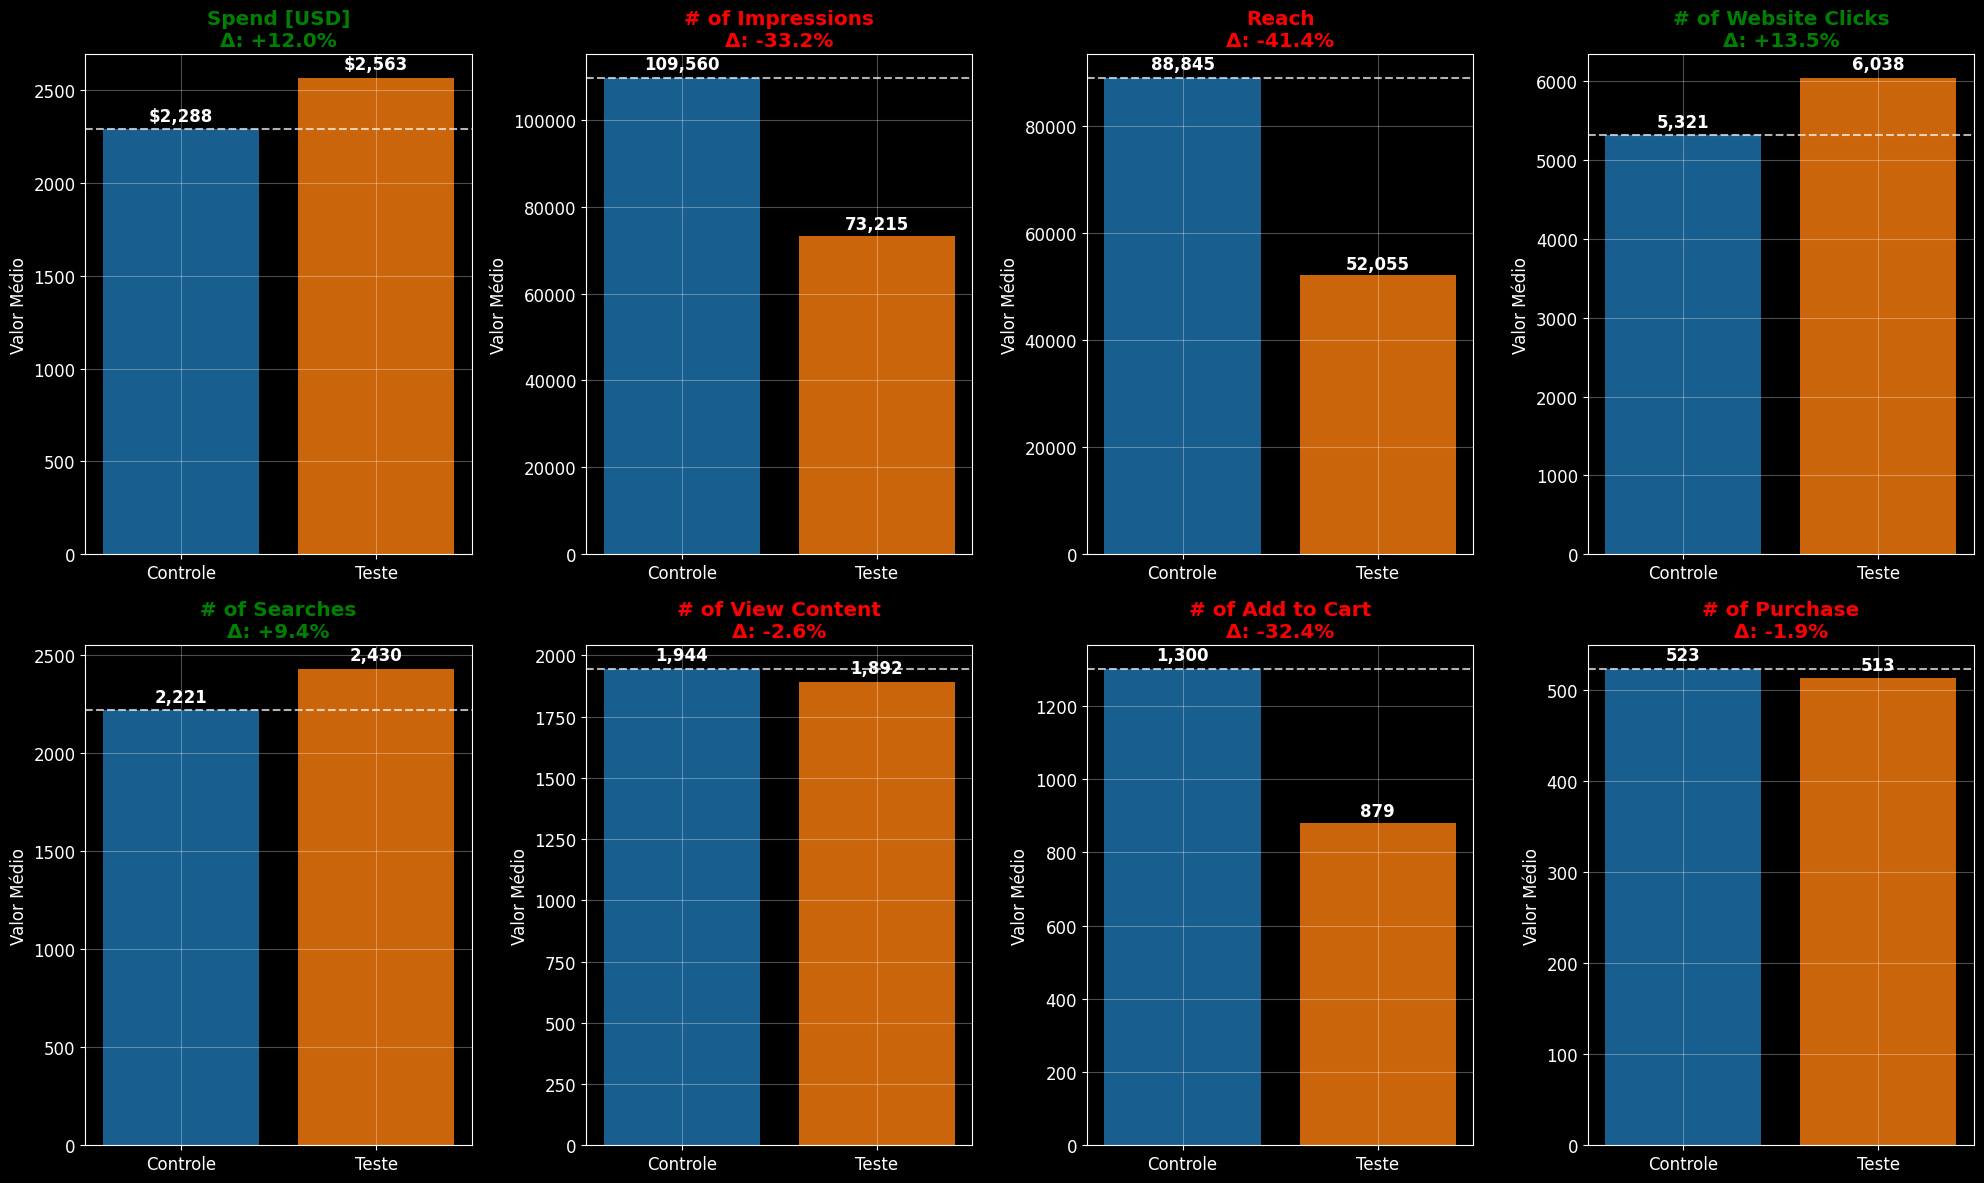

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
axes = axes.ravel()

for i, metric in enumerate(metrics):
    # Calcular médias
    mean_control = df_CG_fixed[metric].mean()
    mean_test = df_TG_fixed[metric].mean()
    
    # Criar barras
    bars = axes[i].bar(['Controle', 'Teste'], [mean_control, mean_test], 
                      color=['#1f77b4', '#ff7f0e'], alpha=0.8)
    
    # Adicionar linha de comparação
    axes[i].axhline(y=mean_control, color='white', linestyle='--', alpha=0.7, label='Média Controle')
    
    # Adicionar valores nas barras
    for bar, value in zip(bars, [mean_control, mean_test]):
        height = bar.get_height()
        if metric == 'Spend [USD]':
            axes[i].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                        f'${value:,.0f}', ha='center', va='bottom', fontweight='bold')
        else:
            axes[i].text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                        f'{value:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    # Calcular e mostrar diferença percentual
    pct_diff = ((mean_test - mean_control) / mean_control) * 100 if mean_control != 0 else 0
    diff_color = 'green' if pct_diff > 0 else 'red'
    
    axes[i].set_title(f'{metric}\nΔ: {pct_diff:+.1f}%', color=diff_color, fontweight='bold')
    axes[i].set_ylabel('Valor Médio')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

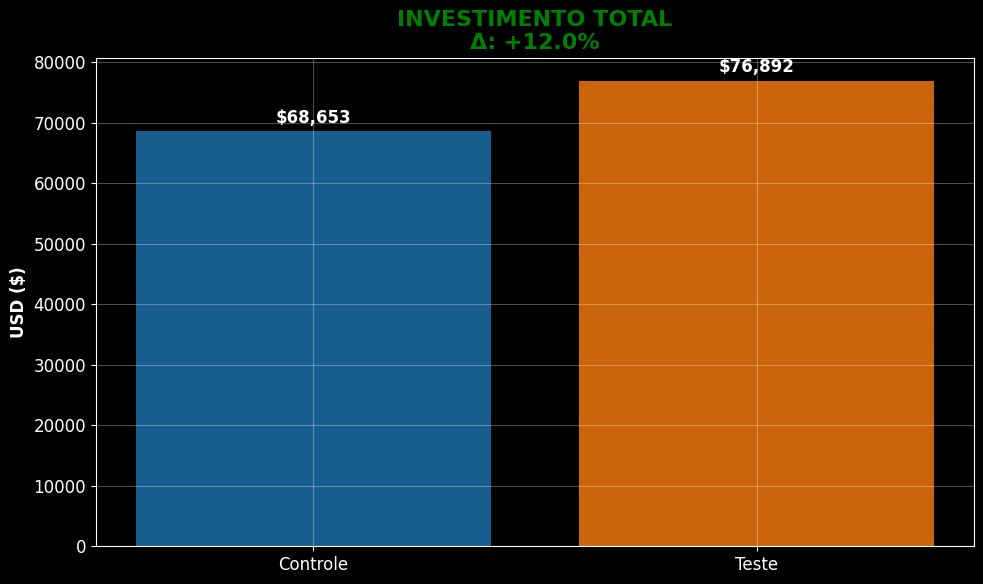

In [32]:
plt.figure(figsize=(10, 6))
total_spend_control = df_CG_fixed['Spend [USD]'].sum()
total_spend_test = df_TG_fixed['Spend [USD]'].sum()

bars = plt.bar(['Controle', 'Teste'], [total_spend_control, total_spend_test], 
               color=['#1f77b4', '#ff7f0e'], alpha=0.8)

# Valores nas barras
for bar, value in zip(bars, [total_spend_control, total_spend_test]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${value:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Diferença percentual
spend_pct_diff = ((total_spend_test - total_spend_control) / total_spend_control) * 100
spend_color = 'green' if spend_pct_diff > 0 else 'red'

plt.title(f'INVESTIMENTO TOTAL\nΔ: {spend_pct_diff:+.1f}%', color=spend_color, fontweight='bold', fontsize=16)
plt.ylabel('USD ($)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


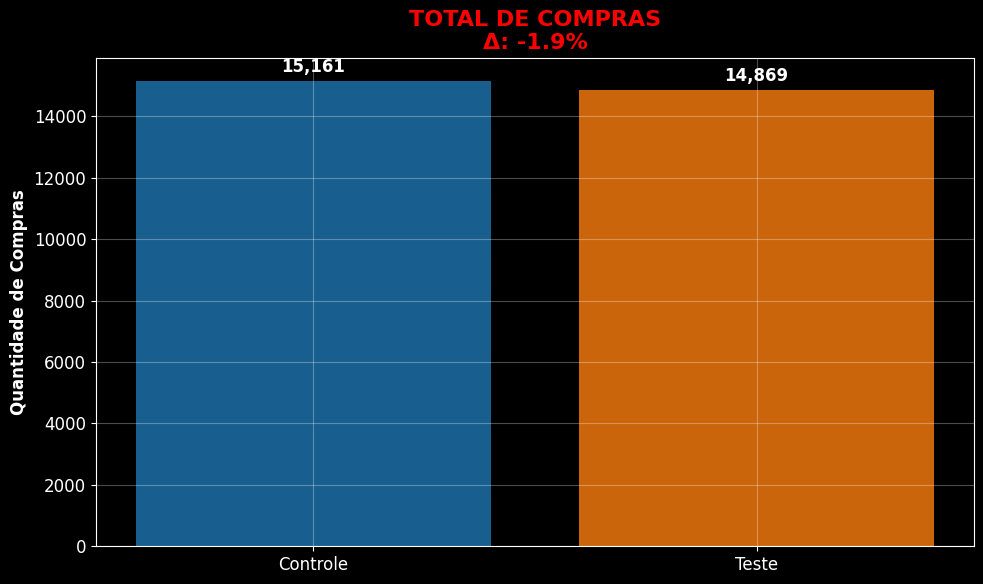

In [33]:
plt.figure(figsize=(10, 6))
total_purchases_control = df_CG_fixed['# of Purchase'].sum()
total_purchases_test = df_TG_fixed['# of Purchase'].sum()

bars = plt.bar(['Controle', 'Teste'], [total_purchases_control, total_purchases_test], 
               color=['#1f77b4', '#ff7f0e'], alpha=0.8)

# Valores nas barras
for bar, value in zip(bars, [total_purchases_control, total_purchases_test]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{value:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Diferença percentual
purchases_pct_diff = ((total_purchases_test - total_purchases_control) / total_purchases_control) * 100
purchases_color = 'green' if purchases_pct_diff > 0 else 'red'

plt.title(f'TOTAL DE COMPRAS\nΔ: {purchases_pct_diff:+.1f}%', color=purchases_color, fontweight='bold', fontsize=16)
plt.ylabel('Quantidade de Compras', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

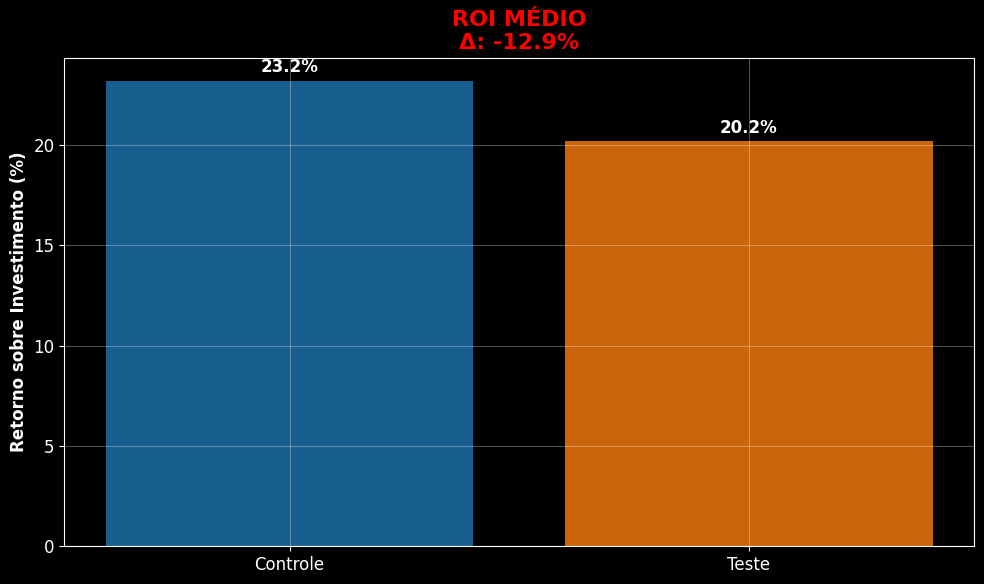

In [34]:
plt.figure(figsize=(10, 6))
roi_control = df_CG_fixed['ROI'].mean()
roi_test = df_TG_fixed['ROI'].mean()

bars = plt.bar(['Controle', 'Teste'], [roi_control, roi_test], 
               color=['#1f77b4', '#ff7f0e'], alpha=0.8)

# Valores nas barras
for bar, value in zip(bars, [roi_control, roi_test]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{value:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Diferença percentual
roi_pct_diff = ((roi_test - roi_control) / roi_control) * 100
roi_color = 'green' if roi_pct_diff > 0 else 'red'

plt.title(f'ROI MÉDIO\nΔ: {roi_pct_diff:+.1f}%', color=roi_color, fontweight='bold', fontsize=16)
plt.ylabel('Retorno sobre Investimento (%)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


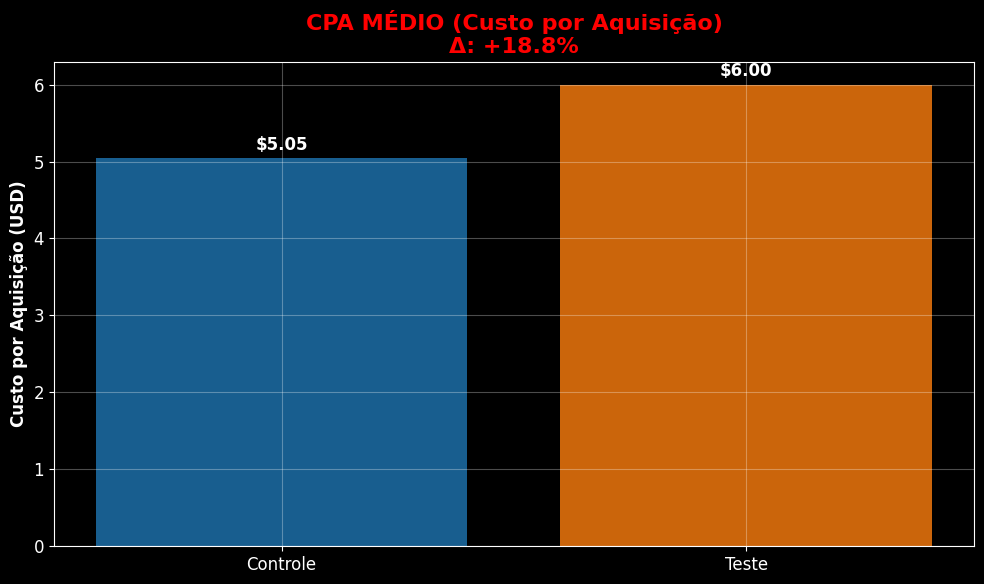

In [35]:
plt.figure(figsize=(10, 6))
cpa_control = df_CG_fixed['CPA'].mean()
cpa_test = df_TG_fixed['CPA'].mean()

bars = plt.bar(['Controle', 'Teste'], [cpa_control, cpa_test], 
               color=['#1f77b4', '#ff7f0e'], alpha=0.8)

# Valores nas barras
for bar, value in zip(bars, [cpa_control, cpa_test]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'${value:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Diferença percentual (invertida porque CPA menor é melhor)
cpa_pct_diff = ((cpa_test - cpa_control) / cpa_control) * 100
cpa_color = 'red' if cpa_pct_diff > 0 else 'green'  # Verde quando CPA diminui

plt.title(f'CPA MÉDIO (Custo por Aquisição)\nΔ: {cpa_pct_diff:+.1f}%', color=cpa_color, fontweight='bold', fontsize=16)
plt.ylabel('Custo por Aquisição (USD)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== RESUMO EXECUTIVO - ANÁLISE FINANCEIRA ===


/tmp/ipykernel_9791/3542314905.py:75: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/art/test_AB_projeto/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


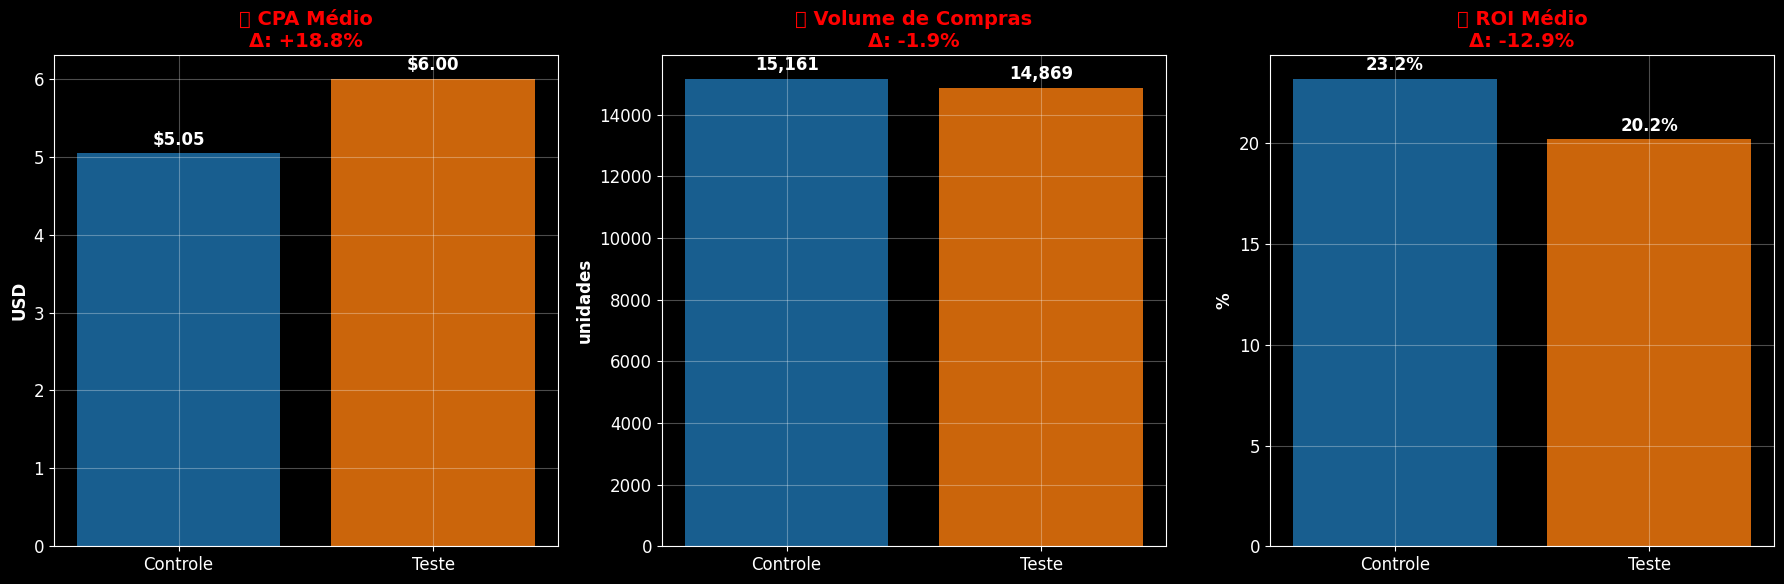


🎯 CONCLUSÃO FINAL - RECOMENDAÇÃO ESTRATÉGICA

📊 RESUMO DAS MÉTRICAS CRÍTICAS:
   • CPA MÉDIO: Teste +18.8% mais caro
   • VOLUME DE COMPRAS: Teste -1.9% menor
   • ROI MÉDIO: Teste -12.9% menor

💡 ANÁLISE:
   ✅ CAMPANHA CONTROLE: Mais eficiente e lucrativa
   ❌ CAMPANHA TESTE: Menos eficiente e mais cara

🎯 RECOMENDAÇÃO ESTRATÉGICA:
   🏆 MANTER CAMPANHA DE CONTROLE
   📉 DESCARTAR CAMPANHA DE TESTE
   🔍 INVESTIGAR por que o teste performou pior

💰 IMPACTO FINANCEIRO:
   • Custo extra por venda: $0.95
   • Custo total adicional: $14,089.13


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar tema escuro
plt.style.use('dark_background')
sns.set_palette("husl")

print("=== RESUMO EXECUTIVO - ANÁLISE FINANCEIRA ===")

# Criar gráfico com as 3 métricas decisivas
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Dados das métricas críticas
metrics_data = {
    'CPA Médio': {
        'control': df_CG_fixed['CPA'].mean(),
        'test': df_TG_fixed['CPA'].mean(),
        'pct_diff': +18.8,  # Dado da sua análise
        'unit': 'USD',
        'better_lower': True  # CPA menor é melhor
    },
    'Volume de Compras': {
        'control': df_CG_fixed['# of Purchase'].sum(),
        'test': df_TG_fixed['# of Purchase'].sum(), 
        'pct_diff': -1.9,  # Dado da sua análise
        'unit': 'unidades',
        'better_lower': False  # Compras maiores são melhores
    },
    'ROI Médio': {
        'control': df_CG_fixed['ROI'].mean(),
        'test': df_TG_fixed['ROI'].mean(),
        'pct_diff': -12.9,  # Dado da sua análise
        'unit': '%',
        'better_lower': False  # ROI maior é melhor
    }
}

# Plotar cada métrica
for i, (metric_name, data) in enumerate(metrics_data.items()):
    ax = [ax1, ax2, ax3][i]
    
    values = [data['control'], data['test']]
    colors = ['#1f77b4', '#ff7f0e']
    
    bars = ax.bar(['Controle', 'Teste'], values, color=colors, alpha=0.8)
    
    # Adicionar valores nas barras
    for bar, value in zip(bars, values):
        height = bar.get_height()
        if data['unit'] == 'USD':
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'${value:.2f}', ha='center', va='bottom', fontweight='bold')
        elif data['unit'] == '%':
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
                   f'{value:,.0f}', ha='center', va='bottom', fontweight='bold')
    
    # Cor do delta baseada no que é melhor
    if (data['pct_diff'] > 0 and data['better_lower']) or (data['pct_diff'] < 0 and not data['better_lower']):
        delta_color = 'red'  # Pior performance
        delta_symbol = '📉'
    else:
        delta_color = 'green'  # Melhor performance  
        delta_symbol = '📈'
    
    ax.set_title(f'{delta_symbol} {metric_name}\nΔ: {data["pct_diff"]:+.1f}%', 
                color=delta_color, fontweight='bold', fontsize=14)
    ax.set_ylabel(data['unit'], fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# CONCLUSÃO FINAL
print("\n" + "="*60)
print("🎯 CONCLUSÃO FINAL - RECOMENDAÇÃO ESTRATÉGICA")
print("="*60)

print(f"\n📊 RESUMO DAS MÉTRICAS CRÍTICAS:")
print(f"   • CPA MÉDIO: Teste {metrics_data['CPA Médio']['pct_diff']:+.1f}% mais caro")
print(f"   • VOLUME DE COMPRAS: Teste {metrics_data['Volume de Compras']['pct_diff']:+.1f}% menor")  
print(f"   • ROI MÉDIO: Teste {metrics_data['ROI Médio']['pct_diff']:+.1f}% menor")

print(f"\n💡 ANÁLISE:")
print(f"   ✅ CAMPANHA CONTROLE: Mais eficiente e lucrativa")
print(f"   ❌ CAMPANHA TESTE: Menos eficiente e mais cara")

print(f"\n🎯 RECOMENDAÇÃO ESTRATÉGICA:")
print(f"   🏆 MANTER CAMPANHA DE CONTROLE")
print(f"   📉 DESCARTAR CAMPANHA DE TESTE") 
print(f"   🔍 INVESTIGAR por que o teste performou pior")

print(f"\n💰 IMPACTO FINANCEIRO:")
cpa_difference = metrics_data['CPA Médio']['test'] - metrics_data['CPA Médio']['control']
total_test_purchases = metrics_data['Volume de Compras']['test']
extra_cost = cpa_difference * total_test_purchases

print(f"   • Custo extra por venda: ${cpa_difference:.2f}")
print(f"   • Custo total adicional: ${extra_cost:,.2f}")

print("="*60)